<a href="https://colab.research.google.com/github/KrithikChidM/PrmlLab/blob/main/LAB3/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


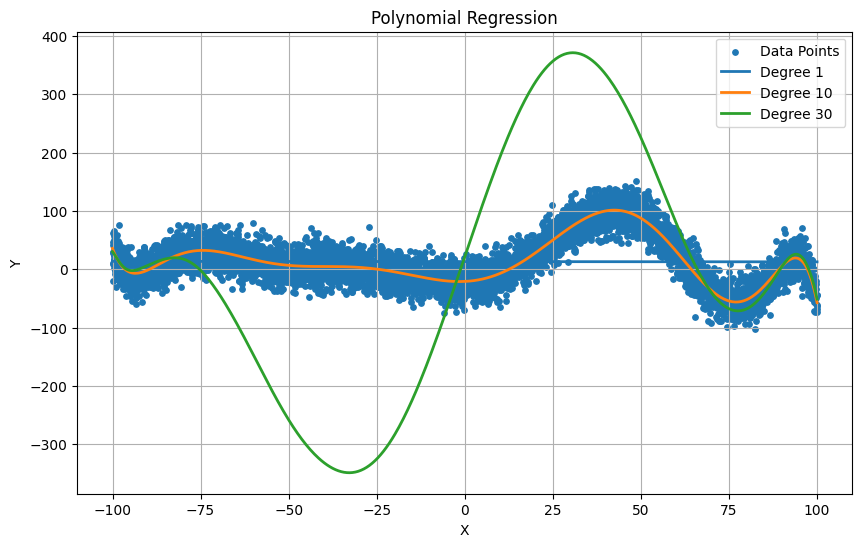

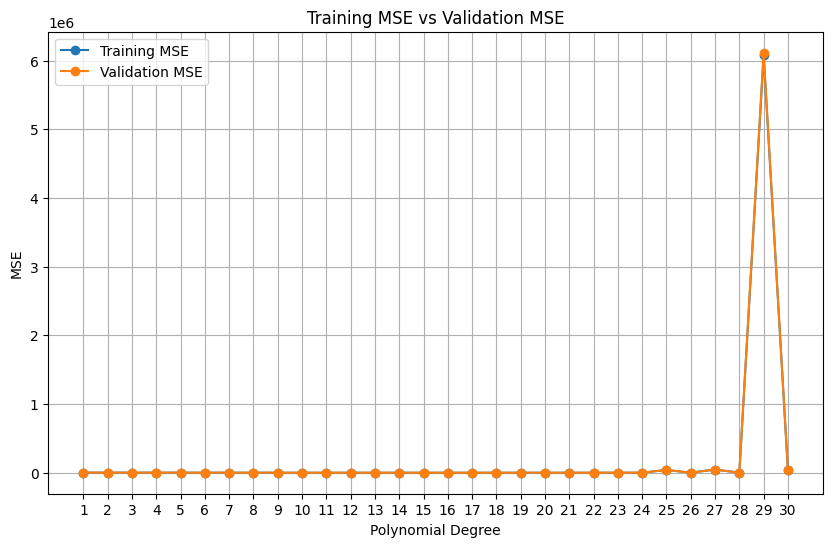

Best Degree: 10
Weights: [-2.07316078e+01  2.86309293e-01  9.64592485e-02  1.61717068e-03
 -3.97389461e-05 -8.48808176e-07  5.39355303e-09  1.29618675e-10
 -2.32096550e-13 -6.16608029e-15 -5.31852668e-19]
Training MSE: 364.85209744690985
Testing MSE: 371.74910784760954
Validation MSE: 346.4541073825508

Degree | Training MSE | Validation MSE
1 | 1746.627528041287 | 1718.5309019932984
2 | 1701.0515617411284 | 1688.180105958756
3 | 1467.6189538810627 | 1437.4169038727407
4 | 1401.905739264853 | 1362.7549032841146
5 | 1043.0742957142954 | 1028.3469983794776
6 | 716.5711069450833 | 700.7525346026438
7 | 716.2216524893574 | 699.7134693722536
8 | 586.0272275081638 | 567.29035030999
9 | 364.8561877237794 | 346.51243629342844
10 | 364.85209744690985 | 346.4541073825508
11 | 364.85149560573353 | 346.47180260594627
12 | 364.8500530402979 | 346.49260543756475
13 | 364.8498792533092 | 346.50664218588787
14 | 364.76932398483183 | 346.67240058499
15 | 364.76931021395234 | 346.67128937407915
16 | 364

In [4]:
import numpy as np
import matplotlib.pyplot as plt

filename = "/content/drive/MyDrive/Krithik SNU/HAM/noisy_7.txt"

data = np.loadtxt(filename)
X = data[:, 0]
Y = data[:, 1]

np.random.seed(42)
idx = np.random.permutation(len(X))

n_train = int(0.70 * len(X))
n_test = int(0.15 * len(X))

train_idx = idx[:n_train]
test_idx = idx[n_train:n_train + n_test]
val_idx = idx[n_train + n_test:]

X_train, Y_train = X[train_idx], Y[train_idx]
X_test, Y_test = X[test_idx], Y[test_idx]
X_val, Y_val = X[val_idx], Y[val_idx]

degrees = np.arange(1, 31)
train_errors = np.zeros(30)
test_errors = np.zeros(30)
validation_errors = np.zeros(30)
weights = {}

for d in degrees:
    Xtr = np.column_stack([X_train ** j for j in range(d + 1)])

    w = np.linalg.inv(Xtr.T @ Xtr) @ Xtr.T @ Y_train
    weights[d] = w

    Xte = np.column_stack([X_test ** j for j in range(d + 1)])
    Xva = np.column_stack([X_val ** j for j in range(d + 1)])

    Y_train_pred = Xtr @ w
    Y_test_pred = Xte @ w
    Y_val_pred = Xva @ w

    train_errors[d - 1] = np.mean((Y_train - Y_train_pred) ** 2)
    test_errors[d - 1] = np.mean((Y_test - Y_test_pred) ** 2)
    validation_errors[d - 1] = np.mean((Y_val - Y_val_pred) ** 2)

best_degree = degrees[np.argmin(validation_errors)]
w = weights[best_degree]

# Degree 1, 9 and 30 curves with data points
X_plot = np.linspace(X.min(), X.max(), 500)

plt.figure(figsize=(10, 6))
plt.scatter(X_train, Y_train, s=15, label="Data Points")

for d in [1, 10, 30]:
    Xp = np.column_stack([X_plot ** j for j in range(d + 1)])
    Yp = Xp @ weights[d]
    plt.plot(X_plot, Yp, linewidth=2, label="Degree " + str(d))

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polynomial Regression")
plt.legend()
plt.grid()
plt.show()

# Training vs Validation MSE
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, marker="o", label="Training MSE")
plt.plot(degrees, validation_errors, marker="o", label="Validation MSE")

plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Training MSE vs Validation MSE")
plt.xticks(degrees)
plt.legend()
plt.grid()
plt.show()

print("Best Degree:", best_degree)
print("Weights:", weights[best_degree])
print("Training MSE:", train_errors[best_degree - 1])
print("Testing MSE:", test_errors[best_degree - 1])
print("Validation MSE:", validation_errors[best_degree - 1])

print("\nDegree | Training MSE | Validation MSE")

for d in degrees:
    print(d, "|", train_errors[d - 1], "|", validation_errors[d - 1])